In [1]:
from functions import lowess
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from scipy.stats import ks_2samp
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')
import statsmodels.api as sm

from astropy.coordinates import SkyCoord  # High-level coordinates
from astropy.coordinates import ICRS, Galactic, FK4, FK5  # Low-level frames
from astropy.coordinates import Angle, Latitude, Longitude  # Angles
import astropy.units as u
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
palette = 'viridis'
font = {'color':  'black', 'weight': 'normal','size': 14}
font_cb = {'color':  'black', 'weight': 'normal','size': 12}
labelsize = 12

In [2]:
df = pd.read_csv('Dados/results.csv', index_col = 'Cluster')
bdata = pd.read_csv('Dados/data.csv', index_col ='Cluster')

In [8]:
df.FeH.describe()

count    771.000000
mean      -0.035634
std        0.107249
min       -0.373000
25%       -0.113500
50%       -0.036000
75%        0.032000
max        0.426000
Name: FeH, dtype: float64

In [ ]:
def classificar_metalicidade(m):
    if m < -0:
        return '[Fe/H]<0'
    else:
        return '[Fe/H]>0'
aux = data.copy(deep=True)
aux['FeH_class'] = aux['FeH'].apply(classificar_metalicidade)
df['FeH_class'] = df['FeH'].apply(classificar_metalicidade)

In [ ]:
aux  = aux[aux.q>0]

In [ ]:
aux['FeH_class'].value_counts()

ValueError: Could not interpret value `bin_frac` for `x`. An entry with this name does not appear in `data`.

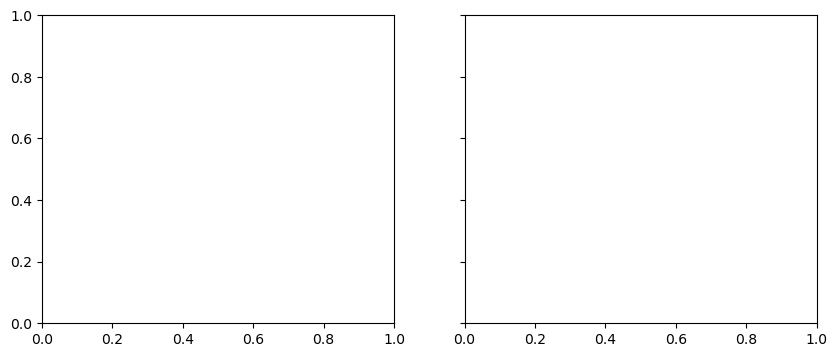

In [6]:
fig, axs = plt.subplots(1,2, figsize=(10,4), sharey=True)


sns.histplot(data=aux, x='bin_frac', hue='FeH_class', bins=12,
                   element='step', fill=None, stat='percent', legend=False, ax=axs[0], hue_order=['[Fe/H]<0', '[Fe/H]>0'])

axs[0].axvline(df[df.FeH<-0.1].bin_frac.median(), color='orange', linestyle='--')
axs[0].axvline(df[df.FeH>=-0.1].bin_frac.median(), color='b', linestyle='--', alpha=0.5)

sns.histplot(data=aux, x='q', hue='FeH_class', bins=12, hue_order=['[Fe/H]<0', '[Fe/H]>0'],
                   element='step', fill=None, stat='percent', legend=False, ax=axs[1])

axs[1].axvline(aux[aux.FeH<-0.1].q.median(), color='gray', linestyle='--')


axs[0].set_xlabel('Binary fraction', fontdict=font)
axs[1].set_xlabel('Mass ratio', fontdict=font)
axs[0].set_ylabel('Percent [%]', fontdict=font)
axs[1].legend(title='', labels=['[Fe/H]<0', '[Fe/H]>0']) 
axs[0].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[1].tick_params(labelleft=True, labelbottom=True, labelsize=12)
#plt.savefig('Figures/hist_mass_ratio_metalicidade.png', bbox_inches='tight', dpi=300)
plt.show()

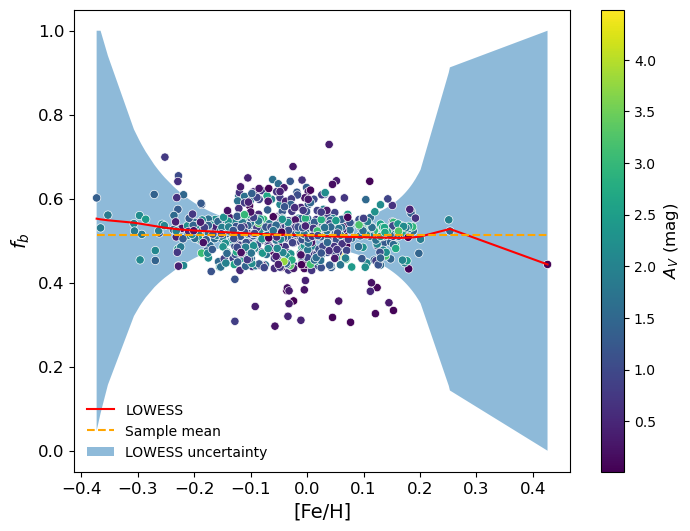

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))

X = df.FeH.values
Y = df.bin_frac_corr.values

#AJUSTANDO O LOWESS
order = np.argsort(X)
y_sm, y_std = lowess(X,Y, f=0.3)
ax.plot(X[order], y_sm[order], color='red', label='LOWESS')
ax.hlines(Y.mean(),X.min(),X.max(),colors='orange',linestyles='--',label='Sample mean')
ax.fill_between(X[order],
                np.where((y_sm[order] - 1.96*y_std[order])<0, 0 , y_sm[order] - 1.96*y_std[order]),
                np.where((y_sm[order] + 1.96*y_std[order])>1, 1 , y_sm[order] + 1.96*y_std[order]), 
                alpha=0.5, label='LOWESS uncertainty')

sc = sns.scatterplot(data=df, x='FeH', y='bin_frac_corr', hue='Av', palette=palette, legend=False, ax=ax,)


norm = mpl.colors.Normalize(
    vmin=df['Av'].min(skipna=True),
    vmax=df['Av'].max(skipna=True)
)

cm_ = mpl.cm.ScalarMappable(norm=norm, cmap=palette)
cm_.set_array([])

cbar = fig.colorbar(cm_, ax=ax)
cbar.set_label(r'$A_V$ (mag)', fontdict=font_cb)

ax.set_xlabel('[Fe/H]', fontdict=font)
ax.set_ylabel(r'$f_b$', fontdict=font)
ax.tick_params(labelsize=labelsize)
#ax.set_ylim(0,1)
ax.legend(frameon=False, loc = 'lower left')
plt.savefig('Figures/dist_fb_metalicidade.png', bbox_inches='tight', dpi=300)
plt.show()
